### `SqliteSaver`
- LangGraph 상태를  SQLite DB에 저장하는 체크포인터

<br>

- 설치

In [1]:
# ! pip install langgraph-checkpoint-sqlite

<br>

#### 사용 방식

<table>
<thead>
<tr>
<th style="text-align: left;">특징</th>
<th style="text-align: left;">방식 1 (직접 연결)</th>
<th style="text-align: left;">방식 2 (Context Manager)</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong>리소스 관리</strong></td>
<td style="text-align: left;">수동 (close 필요)</td>
<td style="text-align: left;">자동 (with 블록)</td>
</tr>
<tr>
<td style="text-align: left;"><strong>안전성</strong></td>
<td style="text-align: left;">낮음</td>
<td style="text-align: left;">높음 ✅</td>
</tr>
<tr>
<td style="text-align: left;"><strong>권장 상황</strong></td>
<td style="text-align: left;">연결 재사용 시</td>
<td style="text-align: left;">일반적인 사용</td>
</tr>
</tbody>
</table>

<br>

1. **직접 연결 관리**
- 데이터베이스 연결을 직접 생성하고 관리하는 방식
- 연결을 재사용하는 경우 유용
  
<br>

- 반드시 `conn.close()`를 호출하여 연결을 종료
- `try-finally` 블록으로 예외 발생 시에도 안전하게 종료되도록 구현
- 연결을 닫지 않으면 파일 잠금 문제가 발생 가능

In [2]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent

- 데이터베이스 연결 생성

In [3]:
conn = sqlite3.connect("./DB/checkpoints.db", check_same_thread=False)

- **체크포인터 생성 : 연결 객체를 직접 전달하여 체크포인터 생성**

In [4]:
checkpointer = SqliteSaver(conn)

- 그래프 생성 및 컴파일

In [5]:
def chatbot(state: MessagesState):
    """간단한 챗봇 노드"""
    agent = create_agent(model="openai:gpt-4.1-mini", tools=[])
    response = agent.invoke(state)
    return {"messages": response["messages"]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

- 체크포인터 연결

In [7]:
graph = builder.compile(checkpointer=checkpointer)

- 그래프 실행

In [8]:
try:
    config = {"configurable": {"thread_id": "user-001"}}

    # 첫 번째 메시지
    response = graph.invoke(
        {"messages": [{"role": "user", "content": "안녕하세요. 저는 김철수입니다."}]},
        config=config
    )
    print(response["messages"][-1].content)

    # 두 번째 메시지 (히스토리 유지됨)
    response = graph.invoke(
        {"messages": [{"role": "user", "content": "제 이름은 무엇인가요?"}]},
        config=config
    )
    print(response["messages"][-1].content)

finally:
    conn.close()

안녕하세요, 김철수님! 다시 만나서 반갑습니다. 오늘은 어떻게 도와드릴까요?
고객님께서 최근에 알려주신 이름은 김철수입니다. 혹시 바뀌셨다면 알려주세요!


<br>

2. **Context Manager (권장)**

In [9]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent

- 그래프 정의

In [10]:
def chatbot(state: MessagesState):
    """간단한 챗봇 노드"""
    agent = create_agent(model="openai:gpt-4.1-mini", tools=[])
    response = agent.invoke(state)
    return {"messages": response["messages"]}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

- **Context Manager로 체크포인터 생성 및 사용**

In [12]:
with SqliteSaver.from_conn_string("./DB/checkpoints.db") as checkpointer:
    # 그래프 컴파일
    graph = builder.compile(checkpointer=checkpointer)

    # 여러 세션 처리
    # 사용자 1의 세션
    config_user1 = {"configurable": {"thread_id": "user-001"}}
    response = graph.invoke(
        {"messages": [{"role": "user", "content": "제 이름은 철수입니다"}]},
        config=config_user1
    )
    print(f"User 1: {response['messages'][-1].content}")

    # 사용자 2의 세션 (독립적인 히스토리)
    config_user2 = {"configurable": {"thread_id": "user-002"}}
    response = graph.invoke(
        {"messages": [{"role": "user", "content": "제 이름은 영희입니다"}]},
        config=config_user2
    )
    print(f"User 2: {response['messages'][-1].content}")

    # 상태 조회
    # 사용자 1의 현재 상태 확인
    state = graph.get_state(config_user1)
    print(f"User 1 메시지 수: {len(state.values['messages'])}")

User 1: 네, 철수님! 알겠습니다. 앞으로 철수님으로 기억하겠습니다. 어떻게 도와드릴까요?
User 2: 안녕하세요, 영희님! 다시 만나서 반갑습니다. 어떤 도움을 드릴까요?
User 1 메시지 수: 14


<br>

#### 연결 문자열 형식
- `SqliteSaver`는 다양한 형식의 연결 문자열을 지원

<br>

- 파일 경로 (현재 디렉토리)

In [13]:
with SqliteSaver.from_conn_string("./DB/checkpoints.db") as checkpointer:
    # 현재 디렉토리에 checkpoints.db 파일 생성
    pass

- 하위 폴더 경로

In [14]:
import os

In [15]:
os.makedirs("DB", exist_ok=True)

with SqliteSaver.from_conn_string("DB/checkpoints.db") as checkpointer:
    # DB 폴더에 checkpoints.db 파일 생성
    pass

- 인메모리 데이터베이스 (휘발성)

In [16]:
with SqliteSaver.from_conn_string(":memory:") as checkpointer:
    # 메모리에만 저장, 프로세스 종료 시 데이터 소실
    # 테스트나 임시 작업에 유용
    pass

<br>

#### 비동기 체크포인터: `AsyncSqliteSaver`
- **동시 다발적인 요청을 처리해야 하는 웹 서버 환경에서는 비동기 버전을 사용**


<table>
<thead>
<tr>
<th style="text-align: left;">상황</th>
<th style="text-align: center;">동기 (SqliteSaver)</th>
<th style="text-align: center;">비동기 (AsyncSqliteSaver)</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;">CLI 스크립트</td>
<td style="text-align: center;">✅ 권장</td>
<td style="text-align: center;">❌ 불필요</td>
</tr>
<tr>
<td style="text-align: left;">FastAPI 웹 서버</td>
<td style="text-align: center;">❌ 블로킹</td>
<td style="text-align: center;">✅ 필수</td>
</tr>
<tr>
<td style="text-align: left;">동시 사용자 처리</td>
<td style="text-align: center;">❌ 느림</td>
<td style="text-align: center;">✅ 빠름</td>
</tr>
<tr>
<td style="text-align: left;">간단한 테스트</td>
<td style="text-align: center;">✅ 편함</td>
<td style="text-align: center;">❌ 복잡함</td>
</tr>
</tbody>
</table>

<br>

In [17]:
# pip install langgraph-checkpoint-sqlite aiosqlite==0.21.0

In [18]:
import asyncio
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent

- 비동기 그래프 정의

In [19]:
async def chatbot(state: MessagesState):
    """비동기 챗봇 노드"""
    agent = create_agent(model="openai:gpt-4.1-mini", tools=[])
    # ainvoke로 비동기 호출
    response = await agent.ainvoke(state)
    return {"messages": response["messages"]}

In [20]:
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

<br>

- **비동기 `main()` 함수**

In [21]:
async def main():
    # async with로 비동기 context manager 사용
    async with AsyncSqliteSaver.from_conn_string("checkpoints.db") as checkpointer:
        # 그래프 컴파일
        graph = builder.compile(checkpointer=checkpointer)

        # 비동기 그래프 실행
        config = {"configurable": {"thread_id": "user-001"}}

        # ainvoke로 비동기 호출
        response = await graph.ainvoke(
            {"messages": [{"role": "user", "content": "안녕하세요"}]},
            config=config
        )
        print(response["messages"][-1].content)

        # 비동기 상태 조회
        # aget_state로 비동기 상태 조회
        state = await graph.aget_state(config)
        print(f"메시지 수: {len(state.values['messages'])}")

- 실행

In [22]:
# asyncio.run(main())

await main()

안녕하세요! 어떻게 도와드릴까요?
메시지 수: 2


<br>

#### 여러 사용자 동시 처리
- **동기 vs 비동기 처리 시간**:
    - 동기 (순차 처리): 사용자 10명 × 2초 = 20초
    - 비동기 (병렬 처리): 약 2~3초 (동시 처리)
    
    $\rightarrow$ **웹 서버에서 동시 사용자를 처리해야 한다면 비동기가 필수**

In [23]:
import asyncio
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent

- 그래프 구성

In [24]:
async def chatbot(state: MessagesState):
    """비동기 챗봇 노드"""
    agent = create_agent(model="openai:gpt-4.1-mini", tools=[])
    response = await agent.ainvoke(state)
    return {"messages": response["messages"]}

In [25]:
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

- 단일 사용자 처리 함수

In [26]:
async def process_user(graph, user_id: str, message: str):
    """단일 사용자의 메시지를 처리"""
    config = {"configurable": {"thread_id": user_id}}

    response = await graph.ainvoke(
        {"messages": [{"role": "user", "content": message}]},
        config=config
    )

    print(f"[{user_id}] {response['messages'][-1].content}")

- 여러 사용자 동시 처리

In [27]:
async def main():
    async with AsyncSqliteSaver.from_conn_string("./DB/checkpoints.db") as checkpointer:
        graph = builder.compile(checkpointer=checkpointer)

        # asyncio.gather로 10명 동시 처리
        # 순차 처리 대비 약 10배 빠름
        tasks = [
            process_user(graph, f"user-{i:03d}", f"안녕하세요, 저는 사용자 {i}입니다")
            for i in range(1, 11)
        ]

        # 모든 작업이 완료될 때까지 대기
        await asyncio.gather(*tasks)

In [28]:
# asyncio.run(main())

await main()

[user-002] 안녕하세요, 사용자 2님! 반갑습니다. 무엇을 도와드릴까요?
[user-001] 안녕하세요, 사용자 1님! 다시 만나서 반갑습니다. 어떻게 도와드릴까요?
[user-009] 안녕하세요, 사용자 9님! 다시 만나서 반갑습니다. 무엇을 도와드릴까요?
[user-006] 안녕하세요, 사용자 6님! 다시 만나서 반갑습니다. 오늘은 어떻게 도와드릴까요?
[user-005] 안녕하세요, 사용자 5님! 다시 만나서 반갑습니다. 무엇을 도와드릴까요?
[user-004] 안녕하세요, 사용자 4님! 다시 만나서 반가워요. 무엇을 도와드릴까요?
[user-008] 안녕하세요, 사용자 8님! 다시 만나서 반가워요. 오늘은 무엇을 도와드릴까요?
[user-007] 안녕하세요, 사용자 7님! 다시 만나서 반갑습니다. 오늘은 무엇을 도와드릴까요?
[user-003] 안녕하세요, 사용자 3님! 다시 만나서 반갑습니다. 무엇을 도와드릴까요?
[user-010] 안녕하세요, 사용자 10님! 다시 만나서 반갑습니다. 오늘은 어떻게 도와드릴까요?


<br>

<hr>

<br>

### Time Travel - 과거 상태로 이동
- **Time Travel은 LangGraph에서 그래프 실행의 과거 체크포인트로 돌아가 다른 경로를 탐색할 수 있게 해주는 강력한 디버깅 및 탐색 기능**

<img src='img/1-10-1.png' width=800>

<br>

#### Time Travel의 필요성
- **AI 에이전트는 종종 비결정적(Non-deterministic) 특성을 가지므로, 동일한 입력에 대해 다른 결과를 생성할 수 있음**

<br>

- **추론 과정 이해 (Understand Reasoning)**
  - 성공적인 결과로 이끈 의사결정 단계를 역추적하여 분석
  - 각 단계에서 어떤 선택이 이루어졌는지 검토
  - 모델의 추론 패턴과 전략 파악

- **오류 디버깅 (Debug Mistakes)**
  - 잘못된 결과가 발생한 정확한 지점 식별
  - 오류 원인을 단계별로 추적하여 근본 원인 분석
  - 문제가 발생한 특정 노드와 상태 변경 확인

- **대안 탐색 (Explore Alternatives)**
  - 동일한 출발점에서 다른 경로를 시도하여 더 나은 솔루션 발견
  - A/B 테스팅을 통한 최적의 전략 선택
  - 여러 가능성을 탐색하여 모델 성능 개선

<br>

#### Time Travel의 핵심 원리: Fork (분기)
- **과거 체크포인트에서 실행을 제개하면, 원래 실행 이력은 그대로 보존되고, 새로운 분기 (Fork)가 생성**

<br>

- 원래 이력(`CP0` $\rightarrow$ `CP1` $\rightarrow$ `CP2` $\rightarrow$ `CP3`)은 삭제되지 않고 보존
- CP1에서 분기하여 새 이력(`CP4` $\rightarrow$ `CP5`)이 생성
  
  $\rightarrow$ 이 덕분에 원래 결과와 새 결과를 비교 분석 가능


<img src='./img/1-10-2.png' width=300>

<br>

#### Time Travel의 구현

<br>

**Step 1: 체크포인터와 함께 그래프 실행**
- 체크포인터를 설정한 그래프를 실행하여 체크포인트를 생성

<br>



```python
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

class State(TypedDict):
    messages: list

# StateGraph 정의
builder = StateGraph(State)
builder.add_node("node_a", node_a_fn)
builder.add_node("node_b", node_b_fn)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

# 체크포인터와 함께 컴파일
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# 그래프 실행 - 각 노드 실행 후 자동으로 체크포인트 생성
config = {"configurable": {"thread_id": "1"}}
result = graph.invoke({"messages": ["안녕하세요"]}, config=config)
```

<br>

**Step 2: 체크포인트 히스토리 조회**
- **`get_state_history()`** 메서드로 모든 체크포인트를 시간 역순으로 조회
  - `history[0]` : 가장 최근 상태 (실행 완료)
  - `history[-1]` : 최초 상태 (입력 직후)
  - 각 스냅샷의 `config`에는 해당 체크포인트의 `checkpoint_id`가 포함되어 있어, 이 `config`를 그대로 사용하면 해당 시점으로 돌아갈 수 있음

<br>


```python
# 전체 실행 히스토리 조회 (최신순)
history = list(graph.get_state_history(config))

print(f"총 {len(history)}개의 체크포인트:")
for i, snapshot in enumerate(history):
    print(f"{i}. Step {snapshot.metadata.get('step', 'N/A')}")
    print(f"   Checkpoint ID: {snapshot.config['configurable']['checkpoint_id']}")
    print(f"   Next nodes: {snapshot.next}")
```

<br>

**Step 3: 상태 수정 (선택적)**
- 특정 체크포인트로 돌아간 후, **`update_state()`**로 상태를 수정
- **`as_node`** : 어느 노드가 이 업데이트를 수행한 것으로 간주할지 지정
  - `as_node="node_a"` $\rightarrow$ 그래프는 `node_a`가 완료된 것으로 판단 $\rightarrow$ 다음 실행은 `node_b`부터
  - 올바른 `as_node`를 지정해야 다음 실행 노드가 정확하게 결정

<br>

```python
# 특정 체크포인트 선택 (next 필드로 안전하게 찾기)
target_snapshot = None
for snapshot in history:
    if snapshot.next == ("node_b",):  # node_b 실행 직전 체크포인트
        target_snapshot = snapshot
        break

# 상태 수정
graph.update_state(
    target_snapshot.config,
    {"messages": ["수정된 메시지"]},
    as_node="node_a"  # node_a가 업데이트한 것처럼 처리 → 다음은 node_b
)
```

<br>

**Step 4: 체크포인트에서 실행 재개**
- 선택한 체크포인트의 설정을 사용하여 그래프를 다시 실행 $\rightarrow$ 새로운 fork가 생성
- `invoke(None, config)` : `None` 입력은 "새 입력 없이 저장된 상태에서 계속 진행"을 의미
  - 체크포인트의 상태를 그대로 사용하여 다음 단계를 실행
  - 원래 이력은 보존되고, 새로운 분기(fork)가 생성

<br>

```python
# 선택한 체크포인트의 설정으로 재실행
resume_config = target_snapshot.config

# None을 입력으로 전달 - 저장된 상태에서 계속 실행 (새 fork 생성)
result = graph.invoke(None, config=resume_config)
```

<br>



####  번역 품질 개선기 예시
- 번역 $\rightarrow$ 검수 $\rightarrow$ 최종 출력 3단계 워크플로우에서 Time Travel을 활용하여 번역 품질을 개선

In [29]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
from visualize_graph import visualize_graph

In [30]:
class TranslationState(TypedDict):
    original: str
    translated: str
    review: str
    final_output: str

In [31]:
model = init_chat_model("openai:gpt-4o-mini")

In [32]:
def translate(state: TranslationState) -> dict:
    """1단계: 영어 → 한국어 번역"""
    msg = model.invoke(
        f"다음 영어 문장을 한국어로 번역하세요. 번역문만 출력하세요.\n\n{state['original']}"
    )
    print(f"[translate] {msg.content}")
    return {"translated": msg.content}

In [33]:
def review(state: TranslationState) -> dict:
    """2단계: 번역 품질 검수"""
    msg = model.invoke(
        f"다음 번역의 품질을 한 줄로 평가하세요.\n"
        f"원문: {state['original']}\n번역: {state['translated']}"
    )
    print(f"[review] {msg.content}")
    return {"review": msg.content}

In [34]:
def finalize(state: TranslationState) -> dict:
    """3단계: 최종 출력 생성"""
    final = f"번역: {state['translated']}\n검수: {state['review']}"
    print(f"[finalize] 완료")
    return {"final_output": final}

- 그래프 구성

In [35]:
builder = StateGraph(TranslationState)
builder.add_node("translate", translate)
builder.add_node("review", review)
builder.add_node("finalize", finalize)
builder.add_edge(START, "translate")
builder.add_edge("translate", "review")
builder.add_edge("review", "finalize")
builder.add_edge("finalize", END)

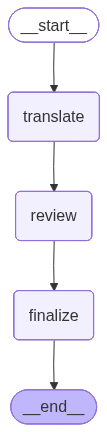

In [36]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

visualize_graph(graph)

- 초기 실행

In [37]:
config = {"configurable": {"thread_id": "translation_1"}}

result = graph.invoke(
    {
        "original": "The early bird catches the worm.",
        "translated": "",
        "review": "",
        "final_output": "",
    },
    config=config,
)

print("\n=== 초기 결과 ===")
print(result["final_output"])

[translate] 일찍 일어나는 새가 벌레를 잡는다.
[review] 번역이 원문의 의미와 어감을 잘 전달하고 있어 품질이 높습니다.
[finalize] 완료

=== 초기 결과 ===
번역: 일찍 일어나는 새가 벌레를 잡는다.
검수: 번역이 원문의 의미와 어감을 잘 전달하고 있어 품질이 높습니다.


- **체크포인트 탐색**


In [38]:
history = list(graph.get_state_history(config))

print(f"총 {len(history)}개의 체크포인트\n")

for i, snapshot in enumerate(history):
    step = snapshot.metadata.get("step", "N/A")
    next_nodes = snapshot.next
    cp_id = snapshot.config["configurable"]["checkpoint_id"]

    print(f"[체크포인트 {i}] Step {step}")
    print(f"  다음 노드: {next_nodes}")
    print(f"  ID: {cp_id[:20]}...")

    # 상태 요약
    vals = snapshot.values
    if vals.get("translated"):
        print(f"  번역: {vals['translated'][:50]}...")
    print()

총 5개의 체크포인트

[체크포인트 0] Step 3
  다음 노드: ()
  ID: 1f15d547-1a2d-6f48-8...
  번역: 일찍 일어나는 새가 벌레를 잡는다....

[체크포인트 1] Step 2
  다음 노드: ('finalize',)
  ID: 1f15d547-1a2b-683c-8...
  번역: 일찍 일어나는 새가 벌레를 잡는다....

[체크포인트 2] Step 1
  다음 노드: ('review',)
  ID: 1f15d547-11ff-645c-8...
  번역: 일찍 일어나는 새가 벌레를 잡는다....

[체크포인트 3] Step 0
  다음 노드: ('translate',)
  ID: 1f15d547-0c55-631b-8...

[체크포인트 4] Step -1
  다음 노드: ('__start__',)
  ID: 1f15d547-0c55-631a-b...



- **Time Travel: 번역 수정 후 재실행** : 번역 결과를 의역으로 변경하고, `review`와 `finalize`를 다시 실행

In [39]:
# review 실행 직전 체크포인트 찾기 (translate 완료 직후)
target = None
for snapshot in history:
    if snapshot.next == ("review",):
        target = snapshot
        break

print(f"선택한 체크포인트: Step {target.metadata.get('step')}")
print(f"현재 번역: {target.values['translated']}")

선택한 체크포인트: Step 1
현재 번역: 일찍 일어나는 새가 벌레를 잡는다.


- **`update_state()`로 번역 수정**

In [42]:
updated_config = graph.update_state(
    target.config,
    {"translated": "부지런한 자가 성공한다."},
    as_node="translate",
)
print("번역 수정 완료: '부지런한 자가 성공한다.'")

번역 수정 완료: '부지런한 자가 성공한다.'


- **수정된 지점에서 재실행 (fork 생성)**
  - `None` 입력으로 재실행 → 새로운 fork 생성

In [43]:
result2 = graph.invoke(None, config=updated_config)
print("\n=== Time Travel 결과 ===")
print(result2["final_output"])

[review] 번역은 의미 전달에 성공했지만, 원문의 직역적 표현을 놓쳤습니다.
[finalize] 완료

=== Time Travel 결과 ===
번역: 부지런한 자가 성공한다.
검수: 번역은 의미 전달에 성공했지만, 원문의 직역적 표현을 놓쳤습니다.


- **동일 시점에서 다른 경로 탐색** : 같은 체크포인트에서 여러 번 분기하여 다양한 번역을 비교

In [44]:
updated_config = graph.update_state(
    target.config,
    {"translated": "일찍 시작하는 사람이 기회를 잡는다."},
    as_node="translate",
)

result3 = graph.invoke(None, config=updated_config)
print("번역 3:", result3["final_output"])

[review] 번역이 원문의 의미를 잘 전달하고 있으며, 자연스럽고 적절한 표현입니다.
[finalize] 완료
번역 3: 번역: 일찍 시작하는 사람이 기회를 잡는다.
검수: 번역이 원문의 의미를 잘 전달하고 있으며, 자연스럽고 적절한 표현입니다.


<br>

#### Time Travel 활용 패턴 

<br>

1. **최적 결과 찾기**

```python
def find_best_translation(graph, config, num_attempts=3):
    """동일 체크포인트에서 여러 번 실행하여 최적 번역 선택"""

    # translate 완료 직후 체크포인트 찾기
    history = list(graph.get_state_history(config))
    target = next(
        (s for s in history if s.next == ("review",)),
        None,
    )
    if not target:
        return None

    # 여러 번 실행하여 결과 수집
    results = []
    for i in range(num_attempts):
        result = graph.invoke(None, config=target.config)
        content = result["final_output"]
        results.append(content)
        print(f"시도 {i+1}: {content[:60]}...")

    return results
```

<br>

2. **오류 복구**

```python
def execute_with_recovery(graph, input_data, config):
    """실행 중 오류 발생 시 이전 체크포인트로 복구"""

    try:
        result = graph.invoke(input_data, config)
        return result
    except Exception as e:
        print(f"오류 발생: {e}")

        # 이전 안정 상태로 복구
        history = list(graph.get_state_history(config))
        if len(history) > 1:
            # 가장 최근에 다음 노드가 있는 체크포인트 찾기
            safe = next(
                (s for s in history if s.next),
                history[1],
            )
            print("이전 체크포인트에서 재시도...")
            return graph.invoke(None, config=safe.config)
        else:
            raise
```

<br>

3. **디버깅 워크플로우**

```python
def debug_execution(graph, config):
    """단계별 실행 내용을 분석하여 디버깅 정보 제공"""

    history = list(graph.get_state_history(config))

    print("=== 실행 흐름 분석 ===\n")

    # 시간순으로 출력 (역순을 다시 뒤집기)
    for i, snapshot in enumerate(reversed(history)):
        step = snapshot.metadata.get("step", "unknown")
        print(f"[단계 {step}]")

        # 실행된 노드 확인
        writes = snapshot.metadata.get("writes", {})
        if writes:
            print(f"  실행된 노드: {list(writes.keys())}")

        # 다음 예정 노드
        if snapshot.next:
            print(f"  다음 노드: {snapshot.next}")

        # 상태 키 요약
        vals = snapshot.values
        print(f"  상태 키: {list(vals.keys())}")
        print()
```

<br>

#### Time Travel vs 일반 재실행

<table>
<thead>
<tr>
<th style="text-align: left;">구분</th>
<th style="text-align: left;">Time Travel</th>
<th style="text-align: left;">일반 재실행</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong>시작점</strong></td>
<td style="text-align: left;">임의의 과거 체크포인트</td>
<td style="text-align: left;">항상 처음부터</td>
</tr>
<tr>
<td style="text-align: left;"><strong>이전 결과 보존</strong></td>
<td style="text-align: left;">보존됨 (fork 생성)</td>
<td style="text-align: left;">덮어씌워짐</td>
</tr>
<tr>
<td style="text-align: left;"><strong>부분 수정</strong></td>
<td style="text-align: left;">특정 단계만 수정 가능</td>
<td style="text-align: left;">전체를 다시 실행</td>
</tr>
<tr>
<td style="text-align: left;"><strong>비용</strong></td>
<td style="text-align: left;">이후 단계만 실행 (효율적)</td>
<td style="text-align: left;">전체 재실행 (비효율적)</td>
</tr>
<tr>
<td style="text-align: left;"><strong>용도</strong></td>
<td style="text-align: left;">디버깅, 최적화, A/B 테스트</td>
<td style="text-align: left;">전체 재시작</td>
</tr>
</tbody>
</table>

<br>

#### Time Travel 사용 시 주의사항
- **체크포인터 필수**: 체크포인터 없이는 Time Travel을 사용할 수 없음
- **비결정성**: LLM은 비결정적이므로 같은 체크포인트에서도 다른 결과가 생성
- **외부 의존성**: 외부 API 호출이나 파일 시스템 접근은 재현되지 않을 수 있음

<br>

<hr>

<br>



### Durable Execution
- Durable Execution(견고한 실행)은 LangGraph의 중단 내성(Fault Tolerance) 기능으로, 그래프 실행이 중단되더라도 진행 상태를 보존하여 나중에 정확히 그 지점부터 재개할 수 있게 해줌
  
  **마치 장시간 게임을 플레이할 때 자동 저장 기능이 있는 것처럼, 실행 과정이 자동으로 저장되어 언제든 복구**

<br>

<img src='./img/1-10-3.png' width=600>

<br>


#### Durable Execution의 필요성
- AI 에이전트 워크플로우는 다음과 같은 이유로 중단될 수 있음
  - Human-in-the-Loop: 인간의 승인이나 입력을 기다리는 동안 장시간 대기
  - 장시간 실행: 복잡한 작업으로 인해 시간 초과 발생
  - 외부 시스템 장애: API 호출 실패, 네트워크 오류 등
  - 서버 재시작: 배포, 유지보수, 시스템 업데이트 등
  
  $\rightarrow$ **Durable Execution을 사용하면 이러한 중단 상황에서도 처음부터 다시 시작할 필요 없이 중단된 지점부터 안전하게 재개 가능**

<br>

#### Durable Execution 사용 조건

<br>

- **Checkpointer로 Persistence 활성화**
  - 체크포인터를 사용하여 상태를 지속적으로 저장

```python
from langgraph.checkpoint.memory import InMemorySaver

# 메모리 기반 (프로세스 종료 시 소실)
checkpointer = InMemorySaver()

graph = workflow.compile(checkpointer=checkpointer)
```

<br>

- **Thread ID 지정**
  - 각 실행 세션을 구분하기 위한 고유 식별자를 제공

```python
# Thread ID로 세션 구분
config = {"configurable": {"thread_id": "user_123_session_1"}}

# 그래프 실행
result = graph.invoke(input_data, config=config)

# 같은 thread_id로 재실행하면 이전 상태에서 계속됨
result2 = graph.invoke(None, config=config)  # 이전 체크포인트에서 재개
```

<br>

- **비결정적 작업은 `@task`로 래핑**
  - **랜덤 값 생성, 현재 시간 조회, LLM 호출 등 비결정적(Non-deterministic) 작업은 반드시 `@task`로 래핑** 
  - `@task`는 StateGraph(Graph API)와 Functional API 모두에서 사용

```python
from langgraph.func import task

# ❌ 잘못된 방법 - 재실행 시 결과가 달라짐
def bad_node(state):
    random_value = random.randint(1, 100)  # 비결정적!
    return {"value": random_value}

# ✅ 올바른 방법 - @task로 래핑 (StateGraph에서도 사용 가능)
@task
def generate_random():
    return random.randint(1, 100)

def good_node(state):
    random_value = generate_random().result()
    return {"value": random_value}
```

<br>

- **LLM 호출도 `@task`로 래핑하면 재실행 시 동일한 결과를 보장**

```python
from langgraph.func import task

@task
def call_llm(prompt: str) -> str:
    """LLM 호출을 @task로 래핑 - 재개 시 캐시에서 복원"""
    response = model.invoke(prompt)
    return response.content

def analyze_node(state):
    # @task로 래핑된 LLM 호출 - interrupt 후 재개해도 같은 결과
    analysis = call_llm(f"분석: {state['data']}").result()
    return {"analysis": analysis}
```

<br>


#### 리플레이 메커니즘
- **워크플로우 재개 시 LangGraph는 정확히 멈춘 코드 줄에서 다시 시작하지 않는 대신 적절한 시작점에서 리플레이**

<img src='./img/1-10-4.png' width=600>

<br>

- **두 방식 모두 `@task`로 래핑한 작업은 재실행 시 캐시에서 결과를 복원하며, 차이점은 체크포인트 단위**
    - **StateGraph**: **노드 경계에서 체크포인트가 생성**되므로, 실패한 노드만 재실행. 노드 내부의 `@task`가 아닌 코드는 재실행
    - **Functional API**: `**@entrypoint` 전체가 재시작되지만, 모든 `@task` 결과가 개별적으로 캐시되어 실질적으로 건너뛰어짐**

<br>

<table>
<thead>
<tr>
<th style="text-align: left;">방식</th>
<th style="text-align: left;">체크포인트 단위</th>
<th style="text-align: left;">재개 동작</th>
<th style="text-align: left;">@task 캐싱</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong>StateGraph</strong></td>
<td style="text-align: left;">노드 실행 후</td>
<td style="text-align: left;">중단된 노드의 시작부터 재실행</td>
<td style="text-align: left;"><code>@task</code> 결과는 캐시에서 복원</td>
</tr>
<tr>
<td style="text-align: left;"><strong>Functional API</strong></td>
<td style="text-align: left;"><code>@entrypoint</code> 레벨</td>
<td style="text-align: left;"><code>@entrypoint</code>부터 재시작</td>
<td style="text-align: left;">완료된 <code>@task</code> 결과 자동 복원</td>
</tr>
</tbody>
</table>

<br>

- **반드시 `@task`로 래핑해야하는 작업**
  - **LLM 호출**: `model.invoke()`, `model.ainvoke()` 등
  - **랜덤 값 생성**: `random.randint()`, `uuid.uuid4()` 등
  - **현재 시간 조회**: `time.time()`, `datetime.now()` 등
  - **외부 API 호출**: HTTP 요청, 데이터베이스 쿼리 등
  
  **이 작업들을 `@task`로 래핑하지 않으면, 워크플로우 재개 시 다른 결과가 생성되어 비결정적 동작이 발생**

<br>

#### Durability Modes
- LangGraph는 세 가지 내구성 모드를 제공하여 성능과 안정성 간의 균형을 조절
- `invoke()`, `stream()` 등 모든 실행 메서드에서 durability 매개변수로 지정

<br>

<table>
<thead>
<tr>
<th style="text-align: left;">모드</th>
<th style="text-align: left;">체크포인트 저장 시점</th>
<th style="text-align: left;">성능</th>
<th style="text-align: left;">안정성</th>
<th style="text-align: left;">용도</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong><code>"exit"</code></strong></td>
<td style="text-align: left;">그래프 실행 완료 시에만</td>
<td style="text-align: left;">가장 빠름</td>
<td style="text-align: left;">낮음</td>
<td style="text-align: left;">빠른 프로토타이핑</td>
</tr>
<tr>
<td style="text-align: left;"><strong><code>"async"</code></strong> (기본)</td>
<td style="text-align: left;">다음 단계와 비동기로 저장</td>
<td style="text-align: left;">빠름</td>
<td style="text-align: left;">중간</td>
<td style="text-align: left;">일반 프로덕션</td>
</tr>
<tr>
<td style="text-align: left;"><strong><code>"sync"</code></strong></td>
<td style="text-align: left;">다음 단계 실행 전 동기 저장</td>
<td style="text-align: left;">느림</td>
<td style="text-align: left;">가장 높음</td>
<td style="text-align: left;">금융/의료 시스템</td>
</tr>
</tbody>
</table>

<br>

```python
# invoke()에서 사용
result = app.invoke(input, config, durability="sync")

# stream()에서 사용
for chunk in app.stream(input, config, durability="sync"):
    print(chunk)

# 기본값 (async) - 일반 프로덕션 환경
result = app.invoke(input, config)
```

<br>

#### 모드 선택

<img src='./img/1-10-5.png' width=300>

<br>

- **`exit`: 빠른 프로토타이핑, 전체 재실행 비용이 낮은 경우**

```
[노드 A] → [노드 B] → [노드 C] → [그래프 종료] → ✅ 저장
                                                     여기서만 저장됨
```

<br>

- **`async` (기본): 대부분의 프로덕션 환경에서 충분**

```
[노드 A 실행] → [노드 B 실행] (동시에 A 저장 중) → [노드 C 실행] (동시에 B 저장 중)
```

<br>

- **`sync`: 금융 거래, 의료 데이터 등 단 하나의 체크포인트도 유실되면 안 되는 경우**

```
[노드 A 실행] → 💾 저장 완료 → [노드 B 실행] → 💾 저장 완료 → [노드 C 실행]
```

<br>

#### Determinism 가이드라인
- **Durable Execution이 올바르게 작동하려면 그래프가 결정론적(Deterministic)이어야 함**

<br>

<table>
<thead>
<tr>
<th style="text-align: left;">타입</th>
<th style="text-align: left;">특징</th>
<th style="text-align: left;">예시</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong>결정론적</strong></td>
<td style="text-align: left;">동일 입력 → 동일 출력</td>
<td style="text-align: left;">수학 함수, 데이터 변환</td>
</tr>
<tr>
<td style="text-align: left;"><strong>비결정론적</strong></td>
<td style="text-align: left;">동일 입력 → 다른 출력</td>
<td style="text-align: left;">LLM 호출, 랜덤값, 현재 시간</td>
</tr>
</tbody>
</table>

<br>

- **비결정적 작업을 `@task`로 래핑하면 결과가 체크포인트에 저장**

```python
from langgraph.func import entrypoint, task
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

@task
def get_stable_random(seed_label: str) -> int:
    """@task로 감싸면 결과가 체크포인트에 저장됨"""
    return random.randint(1, 1000)

@entrypoint(checkpointer=InMemorySaver())
def stable_workflow(inputs):
    val = get_stable_random("A").result()
    human_answer = interrupt(f"랜덤 값 {val}이 생성되었습니다. 계속할까요?")
    return {"random_value": val, "user_response": human_answer}

config = {"configurable": {"thread_id": "stable-demo-001"}}

# Run 1: 첫 실행 (interrupt에서 멈춤)
res1 = stable_workflow.invoke({"id": 1}, config=config)

# Run 2: resume으로 재개 (@task 결과가 캐시에서 복원됨)
res2 = stable_workflow.invoke(Command(resume="네, 계속합니다!"), config=config)
# res2의 random_value는 Run 1에서 생성된 값과 동일
```

<br>

#### Side Effects 처리
- **외부 시스템에 영향을 주는 작업(이메일 발송, 파일 쓰기 등)은 멱등성(Idempotent)을 보장해야 함**

```python
# ❌ 멱등하지 않은 코드 (재실행 시 중복 레코드 생성)
def save_result(state):
    db.insert({"data": state["result"]})  # 재실행 시 중복!

# ✅ 멱등한 코드 (재실행해도 안전)
def save_result(state):
    db.upsert(
        key=state["task_id"],
        data={"data": state["result"]}
    )
```

<br>



#### StateGraph vs Functional API 에러 복구 비교
- `@task` 사용 여부에 따라 에러 발생 시 동작이 달라짐

<br>

- **`@task`를 사용하지 않은 경우**

<table>
<thead>
<tr>
<th style="text-align: left;">특성</th>
<th style="text-align: left;">StateGraph</th>
<th style="text-align: left;">Functional API</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong>에러 시</strong></td>
<td style="text-align: left;">노드 체크포인트 미저장 → 노드 전체 재실행</td>
<td style="text-align: left;"><code>@entrypoint</code>부터 전체 재시작</td>
</tr>
<tr>
<td style="text-align: left;"><strong>재개 동작</strong></td>
<td style="text-align: left;">실패한 노드의 모든 코드 재실행</td>
<td style="text-align: left;">모든 코드 재실행</td>
</tr>
</tbody>
</table>

<br>

- **`@task`를 사용한 경우 (권장)**

<table>
<thead>
<tr>
<th style="text-align: left;">특성</th>
<th style="text-align: left;">StateGraph + @task</th>
<th style="text-align: left;">Functional API + @task</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left;"><strong>에러 시</strong></td>
<td style="text-align: left;">노드 재실행, 단 <code>@task</code> 결과는 캐시 복원</td>
<td style="text-align: left;"><code>@entrypoint</code> 재시작, <code>@task</code> 결과는 캐시 복원</td>
</tr>
<tr>
<td style="text-align: left;"><strong>재개 동작</strong></td>
<td style="text-align: left;"><code>@task</code>가 아닌 코드만 재실행</td>
<td style="text-align: left;">완료된 <code>@task</code>는 건너뛰고 실패한 것만 재시도</td>
</tr>
<tr>
<td style="text-align: left;"><strong>interrupt 시</strong></td>
<td style="text-align: left;"><code>@task</code> 캐싱 정상 동작</td>
<td style="text-align: left;"><code>@task</code> 캐싱 정상 동작</td>
</tr>
</tbody>
</table>

<br>



<br>

<hr>